In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random, math, time
from collections import deque
from copy import deepcopy

np.random.seed(42)
random.seed(42)

# ==============================================================
# 1. SETTING UP THE PROBLEM (The Moving Day Scenario)
# ==============================================================
"""
Imagine we are managing a moving company.
We have a bunch of furniture (items) of different sizes.
We need to pack all this furniture into standard-sized moving trucks (bins).
Our goal: Use the ABSOLUTE MINIMUM number of trucks to save money.
"""

BIN_CAPACITY = 100 # Every moving truck can hold exactly 100 units of stuff.

# We will test our AI on three different moving jobs (Small, Medium, and Large)
INSTANCES = {
    "Small  (N=20)" : [random.randint(10, 70) for _ in range(20)],  # 20 pieces of furniture
    "Medium (N=50)" : [random.randint(10, 70) for _ in range(50)],  # 50 pieces
    "Large  (N=100)": [random.randint(10, 70) for _ in range(100)], # 100 pieces
}

# We will focus most of our deep testing on the Medium job
PRIMARY_KEY   = "Medium (N=50)"
PRIMARY_ITEMS = INSTANCES[PRIMARY_KEY]
N             = len(PRIMARY_ITEMS)

print("=" * 65)
print("  PROBLEM B (EXTENDED): Bin Packing Problem Optimization")
print("=" * 65)
for iname, items in INSTANCES.items():
    # A simple math check: Total volume of furniture divided by truck size.
    # This tells us the absolute best-case scenario (we can never use fewer trucks than this).
    lb = math.ceil(sum(items) / BIN_CAPACITY)
    print(f"  {iname} | Total size={sum(items)} | Lower bound={lb} bins")

# ==============================================================
# 2. THE PACKING RULES & THE BASELINE TEST
# ==============================================================
def first_fit(permutation, items, capacity=BIN_CAPACITY):
    """
    The rule for packing: We are given a list (permutation) of the furniture.
    We pick up the first item on the list and shove it into the first truck that has space.
    If no current truck has space, we are forced to rent a brand new truck.
    Returns: The total number of trucks we had to rent.
    """
    bins = [] # This will keep track of how much empty space is left in each rented truck
    for idx in permutation:
        sz = items[idx]
        placed = False
        for b in range(len(bins)):
            if bins[b] >= sz: # Does this truck have enough space?
                bins[b] -= sz # Put it in, reduce the available space
                placed = True
                break
        if not placed:
            # None of the open trucks had room. Rent a new one!
            bins.append(capacity - sz)
    return len(bins)

def ffd_baseline(items, capacity=BIN_CAPACITY):
    """
    The 'Common Sense' Baseline:
    Any human packer knows you should pack the biggest, bulkiest items first.
    We do this here to get a baseline score. Our AI methods MUST beat this score to be considered 'smart'.
    """
    order = sorted(range(len(items)), key=lambda i: items[i], reverse=True)
    return first_fit(order, items, capacity), order

def fitness(perm, items=PRIMARY_ITEMS):
    # This is how we grade the AI. A lower score (fewer trucks) is better.
    return first_fit(perm, items)

# ==============================================================
# 3. ALGORITHM 1: GENETIC ALGORITHM (Evolution and Breeding)
# ==============================================================
def genetic_algorithm(items=PRIMARY_ITEMS, pop_size=100, max_gen=400, cx_rate=0.85, mut_rate=0.2):
    """
    This method mimics Darwinian evolution.
    1. We create 100 random packing lists (our 'population').
    2. We test them all. The ones that use the fewest trucks survive.
    3. The winners 'breed' to create new packing lists that combine their good ideas.
    """
    n = len(items)

    def rand_ind():
        # Creates a completely random order to pack the furniture
        p = list(range(n)); random.shuffle(p); return p

    def tournament(pop, k=4):
        # Pick 4 random packing lists, let them fight, the one that uses fewer trucks wins
        return min(random.sample(pop, k), key=lambda x: fitness(x, items))

    def pmx_crossover(p1, p2):
        """
        Breeding two packing lists together.
        It takes a chunk of ideas from Parent 1, and fills in the blanks with ideas from Parent 2,
        making sure we don't accidentally pack the same couch twice or forget a chair.
        """
        a, b = sorted(random.sample(range(n), 2))
        child  = p2[:]
        p2_pos = {v: i for i, v in enumerate(p2)}

        for i in range(a, b):
            val = p1[i]
            if child[i] != val:
                j = p2_pos[val]
                child[i], child[j] = child[j], child[i]
                p2_pos[child[j]] = j
                p2_pos[child[i]] = i
        return child

    def inversion_mutate(ind):
        """Mutation: Randomly grab a chunk of the packing list and flip it backwards just to see what happens."""
        a, b = sorted(random.sample(range(n), 2))
        ind[a:b] = ind[a:b][::-1]
        return ind

    # Start with 100 random packing lists
    pop     = [rand_ind() for _ in range(pop_size)]
    elite_n = max(1, pop_size // 20)   # The top 5% smartest lists are granted immortality and survive to the next round

    best_ind = min(pop, key=lambda x: fitness(x, items))
    best_f   = fitness(best_ind, items)
    convergence = []

    # Run the evolution cycle for a set amount of generations
    for gen in range(max_gen):
        pop.sort(key=lambda x: fitness(x, items))
        new_pop = [p[:] for p in pop[:elite_n]]   # Keep the absolute best unchanged

        # Breed the rest to fill up the population again
        while len(new_pop) < pop_size:
            p1 = tournament(pop)
            p2 = tournament(pop)
            child = pmx_crossover(p1, p2) if random.random() < cx_rate else p1[:]
            if random.random() < mut_rate:
                child = inversion_mutate(child)
            new_pop.append(child)

        pop = new_pop

        # Check if the new generation found an all-time best packing list
        cur_best = min(pop, key=lambda x: fitness(x, items))
        cur_f    = fitness(cur_best, items)
        if cur_f < best_f:
            best_f   = cur_f
            best_ind = cur_best[:]

        convergence.append(best_f)

    return best_ind, best_f, convergence

# ==============================================================
# 4. ALGORITHM 2: SIMULATED ANNEALING (Heating and Cooling)
# ==============================================================
def simulated_annealing(items=PRIMARY_ITEMS, max_iter=8000, T_init=30.0, alpha=0.997, reheat_every=1000):
    """
    This method mimics blacksmithing or shaking a box to settle its contents.
    When it's "Hot" (early on), the AI is hyperactive and will accept terrible packing lists just to explore options.
    As it "Cools" down, it becomes strict and will only accept lists that improve the score.
    """
    n = len(items)
    # Start with our "Common Sense" baseline from earlier
    _, current = ffd_baseline(items)
    current_f  = fitness(current, items)

    best   = current[:]
    best_f = current_f

    T = T_init # Start hot
    T_min   = 0.01
    no_imp  = 0
    convergence = []

    for it in range(max_iter):
        # Swap two random pieces of furniture in the packing list
        neighbor = current[:]
        a, b = random.sample(range(n), 2)
        neighbor[a], neighbor[b] = neighbor[b], neighbor[a]
        nbr_f = fitness(neighbor, items)

        # Did the swap make things better? Or, if we are still hot, do we accept a bad swap randomly?
        delta = nbr_f - current_f
        if delta < 0 or (T > T_min and random.random() < math.exp(-delta / T)):
            current   = neighbor[:]
            current_f = nbr_f

        # Save the all-time best score
        if current_f < best_f:
            best_f = current_f
            best   = current[:]
            no_imp = 0
        else:
            no_imp += 1

        # If we have been stuck for 1000 tries, "Reheat" the system to shake things up again
        if no_imp > 0 and no_imp % reheat_every == 0:
            T = max(T_init / 3.0, T)

        # Cool down the temperature slightly for the next round
        T = max(T * alpha, T_min)
        convergence.append(best_f)

    return best, best_f, convergence

# ==============================================================
# 5. ALGORITHM 3: TABU SEARCH (The "Don't Repeat Mistakes" Method)
# ==============================================================
def tabu_search(items=PRIMARY_ITEMS, max_iter=3000, tabu_tenure=15, n_neighbors=30):
    """
    Imagine navigating a maze but bringing a notepad.
    Every time you try a path, you write it down on your "Tabu" (Forbidden) list.
    You force yourself to try NEW paths instead of walking in circles making the same mistakes.
    """
    n = len(items)
    _, current = ffd_baseline(items)
    current_f  = fitness(current, items)

    best   = current[:]
    best_f = current_f

    # The notepad: remembers the last 15 swaps we made so we don't undo them immediately
    tabu_list = deque(maxlen=tabu_tenure)
    convergence = []
    no_imp = 0

    for it in range(max_iter):
        # Look at 30 different possible swaps we could make right now
        neighbors      = []
        neighbor_moves = []

        for _ in range(n_neighbors):
            a, b  = sorted(random.sample(range(n), 2))
            nbr   = current[:]
            nbr[a], nbr[b] = nbr[b], nbr[a]
            neighbors.append(nbr)
            neighbor_moves.append((a, b))

        best_nbr   = None
        best_nbr_f = np.inf
        best_move  = None

        # Go through all 30 options
        for nbr, move in zip(neighbors, neighbor_moves):
            nbr_f = fitness(nbr, items)
            is_tabu = move in tabu_list # Is this move on our forbidden list?

            # We are allowed to make the move if it's NOT forbidden...
            # OR if it IS forbidden but it's so amazingly good that it breaks our all-time record.
            if (not is_tabu) or (nbr_f < best_f):
                if nbr_f < best_nbr_f:
                    best_nbr_f = nbr_f
                    best_nbr   = nbr[:]
                    best_move  = move

        # If every single option was forbidden and terrible, just pick the least terrible one
        if best_nbr is None:
            idx        = np.argmin([fitness(nb, items) for nb in neighbors])
            best_nbr   = neighbors[idx][:]
            best_nbr_f = fitness(best_nbr, items)
            best_move  = neighbor_moves[idx]

        # Add the move we just made to the forbidden list so we don't repeat it soon
        tabu_list.append(best_move)

        current   = best_nbr[:]
        current_f = best_nbr_f

        if current_f < best_f:
            best_f = current_f
            best   = current[:]
            no_imp = 0
        else:
            no_imp += 1

        # If we are completely stuck for 200 turns, dump out all the boxes and start entirely from scratch
        if no_imp > 200:
            p = list(range(n))
            random.shuffle(p)
            current   = p
            current_f = fitness(current, items)
            no_imp    = 0
            tabu_list.clear()

        convergence.append(best_f)

    return best, best_f, convergence

# ==============================================================
# 6. RUNNING THE EXPERIMENT (The Grand Competition)
# ==============================================================
# Because these AI methods use randomness, we must run each of them 30 times.
# Running them once could be lucky. Running them 30 times proves who is actually smartest.
N_RUNS = 30
LB_BINS = math.ceil(sum(PRIMARY_ITEMS) / BIN_CAPACITY)
FFD_BINS, FFD_ORDER = ffd_baseline(PRIMARY_ITEMS)

print(f"\n  Primary Instance: {PRIMARY_KEY}")
print(f"  Theoretical Lower Bound (Perfect Math) : {LB_BINS} bins")
print(f"  FFD Baseline (Human Common Sense)      : {FFD_BINS} bins")
print(f"\n  Running {N_RUNS} independent tests per algorithm...\n")

algorithms = {
    "Genetic Algorithm": genetic_algorithm,
    "SA + Reheating"   : simulated_annealing,
    "Tabu Search"      : tabu_search,
}

all_results   = {}
all_conv      = {}
all_solutions = {}

for name, algo in algorithms.items():
    print(f"  🔁 {name}:", end=" ", flush=True)
    results   = []
    conv_list = []
    best_sol  = None
    best_f    = np.inf

    t0 = time.time() # Start stopwatch
    for run in range(N_RUNS):
        # Change the randomness seed slightly each round so every run is unique but repeatable
        random.seed(run * 13)
        np.random.seed(run * 13)

        # Run the AI
        sol, f, conv = algo()
        results.append(f)
        conv_list.append(conv)

        # Save the best packing list it ever found across all 30 tries
        if f < best_f:
            best_f  = f
            best_sol = sol[:]
        if (run + 1) % 10 == 0:
            print(f"{run+1}.", end=" ", flush=True)

    elapsed = time.time() - t0 # Stop stopwatch
    all_results[name]   = results
    all_conv[name]      = conv_list
    all_solutions[name] = best_sol

    # Print the scorecard for this AI
    arr = np.array(results)
    print(f"\n     Best={int(arr.min())}  Mean={arr.mean():.2f}  "
          f"Std={arr.std():.2f}  Worst={int(arr.max())}  "
          f"Time={elapsed:.1f}s")

# ==============================================================
# 7. MULTI-INSTANCE TESTING (Small, Medium, Large)
# ==============================================================
# Now we do a quick check to see how the AI handles different sized moving jobs.
print("\n" + "=" * 65)
print("  MULTI-INSTANCE RESULTS (Testing on different job sizes)")
print("=" * 65)
print(f"  {'Job Size':<18} {'Best Possible':>13} {'Human Logic':>13} {'GA':>5} {'SA':>5} {'TS':>5}")
print(f"  {'-'*18} {'-'*13} {'-'*13} {'-'*5} {'-'*5} {'-'*5}")

multi_instance_data = {}

for iname, items in INSTANCES.items():
    lb_i   = math.ceil(sum(items) / BIN_CAPACITY)
    ffd_i, _ = ffd_baseline(items)
    row = {"LB": lb_i, "FFD": ffd_i}

    for aname, algo in algorithms.items():
        best = np.inf
        # Test each AI 5 times on the current job size
        for r in range(5):
            random.seed(r); np.random.seed(r)
            _, f, _ = algo(items=items)
            if f < best: best = f
        short = aname.split()[0][:2].upper() if "Tabu" not in aname else "TS"
        row[aname] = int(best)

    multi_instance_data[iname] = row
    ga_b = row['Genetic Algorithm']
    sa_b = row['SA + Reheating']
    ts_b = row['Tabu Search']
    print(f"  {iname:<18} {lb_i:>13} {ffd_i:>13} {ga_b:>5} {sa_b:>5} {ts_b:>5}")

# ==============================================================
# 8. SPACE UTILIZATION (Did we pack them tight?)
# ==============================================================
def get_bin_details(permutation, items=PRIMARY_ITEMS, cap=BIN_CAPACITY):
    # This goes back into our best packing list and measures exactly how much empty air is left in each truck.
    bins = []
    for idx in permutation:
        sz = items[idx]
        placed = False
        for b in range(len(bins)):
            if bins[b][1] >= sz:
                bins[b][0].append(sz); bins[b][1] -= sz; placed = True; break
        if not placed:
            bins.append([[sz], cap - sz])
    return bins

# ==============================================================
# 9. DRAWING THE CHARTS AND GRAPHS
# ==============================================================
colors = {
    "Genetic Algorithm": "#2a9d8f", # Greenish
    "SA + Reheating"   : "#e76f51", # Red/Orange
    "Tabu Search"      : "#6a4c93", # Purple
}

# Create a giant blank canvas for our visual report
fig = plt.figure(figsize=(22, 18))
fig.suptitle("Problem B: Bin Packing Problem — Extended Visual Report",
             fontsize=16, fontweight='bold', y=0.98)

# CHART 1: The Learning Curve. Shows how quickly each AI figured out the problem over time.
ax1 = fig.add_subplot(3, 3, (1, 2))
for name, conv_list in all_conv.items():
    min_len = min(len(c) for c in conv_list)
    arr     = np.array([c[:min_len] for c in conv_list], dtype=float)
    mean_c  = arr.mean(axis=0)
    std_c   = arr.std(axis=0)
    iters   = np.arange(min_len)
    ax1.plot(iters, mean_c, color=colors[name], linewidth=2, label=name)
    ax1.fill_between(iters, mean_c - std_c, mean_c + std_c, color=colors[name], alpha=0.15)
ax1.axhline(LB_BINS, color='red', linestyle='--', linewidth=1.5, label=f'Perfect Math Bound ({LB_BINS} trucks)')
ax1.axhline(FFD_BINS, color='gray', linestyle=':', linewidth=1.5, label=f'Human Logic Baseline ({FFD_BINS} trucks)')
ax1.set_title("Average Learning Curve Over Time (30 runs)", fontsize=11)
ax1.set_xlabel("Time (Iterations / Generations)")
ax1.set_ylabel("Number of Trucks Used")
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)

# CHART 2: Boxplot. Shows how consistent the AI is. (Are they reliable, or just randomly lucky?)
ax2 = fig.add_subplot(3, 3, 3)
bp  = ax2.boxplot([all_results[n] for n in algorithms],
                  patch_artist=True, notch=True,
                  medianprops=dict(color='black', linewidth=2))
for patch, name in zip(bp['boxes'], algorithms):
    patch.set_facecolor(colors[name]); patch.set_alpha(0.7)
ax2.set_xticks(range(1, len(algorithms) + 1))
ax2.set_xticklabels(["Genetics", "Heating/Cooling", "Tabu Memory"], fontsize=10)
ax2.axhline(LB_BINS, color='red', linestyle='--', linewidth=1.5, label='Perfect Bound')
ax2.axhline(FFD_BINS, color='gray', linestyle=':', linewidth=1.5, label='Human Logic')
ax2.legend(fontsize=9)
ax2.set_title("Consistency Distribution (30 runs)", fontsize=11)
ax2.set_ylabel("Total Trucks Rented")
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

# CHARTS 3, 4, 5: Look at the absolute single best run from each AI method.
for idx, (name, conv_list) in enumerate(all_conv.items()):
    ax = fig.add_subplot(3, 3, 4 + idx)
    best_run = np.argmin(all_results[name])
    ax.plot(conv_list[best_run], color=colors[name], linewidth=2)
    ax.axhline(LB_BINS, color='red', linestyle='--', linewidth=1.2)
    ax.axhline(FFD_BINS, color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(f"{name}\n(Their Absolute Best Try)", fontsize=10)
    ax.set_xlabel("Time")
    ax.set_ylabel("Trucks Used")
    ax.grid(True, linestyle='--', alpha=0.5)

# CHART 6: Bar chart comparing the methods across the Small, Medium, and Large moving jobs.
ax6 = fig.add_subplot(3, 3, 7)
inst_names = list(INSTANCES.keys())
x_pos  = np.arange(len(inst_names))
width  = 0.18
labels = ['Perfect', 'Human Logic', 'Genetics', 'Heating', 'Memory']
clrs   = ['#adb5bd', '#6c757d', colors['Genetic Algorithm'],
          colors['SA + Reheating'], colors['Tabu Search']]
keys   = ['LB', 'FFD', 'Genetic Algorithm', 'SA + Reheating', 'Tabu Search']
for i, (lbl, clr, key) in enumerate(zip(labels, clrs, keys)):
    vals = [multi_instance_data[inst][key] for inst in inst_names]
    ax6.bar(x_pos + i * width, vals, width, label=lbl,
            color=clr, alpha=0.85, edgecolor='black', linewidth=0.5)
ax6.set_xticks(x_pos + 2 * width)
ax6.set_xticklabels(["Small Job", "Medium Job", "Large Job"], fontsize=10)
ax6.set_title("Comparing AI across different Job Sizes", fontsize=11)
ax6.set_ylabel("Trucks Used")
ax6.legend(fontsize=8)
ax6.grid(True, axis='y', linestyle='--', alpha=0.5)

# CHART 7: How full are the trucks? We take the Genetic Algorithm's best answer and inspect every truck.
ax7 = fig.add_subplot(3, 3, 8)
ga_bins_detail = get_bin_details(all_solutions['Genetic Algorithm'])
# Calculate percentage full
utilisations = [(BIN_CAPACITY - rem) / BIN_CAPACITY * 100 for _, rem in ga_bins_detail]
bar_colors = ['#2a9d8f' if u >= 80 else      # Green if packed really well
              '#e9c46a' if u >= 60 else      # Yellow if it's okay
              '#e76f51' for u in utilisations] # Red if we are wasting lots of space
ax7.bar(range(1, len(utilisations) + 1), utilisations,
        color=bar_colors, edgecolor='black', linewidth=0.4)
ax7.axhline(80, color='green', linestyle='--', linewidth=1.2, label='80% Full Threshold')
ax7.set_title("Truck Space Wasted vs Used (Best AI Answer)", fontsize=10)
ax7.set_xlabel("Truck Number")
ax7.set_ylabel("How Full is it? (%)")
ax7.set_ylim(0, 110)
ax7.grid(True, axis='y', linestyle='--', alpha=0.5)
green_p  = mpatches.Patch(color='#2a9d8f', label='≥80% (Great Packing)')
yellow_p = mpatches.Patch(color='#e9c46a', label='60-80% (Okay Packing)')
red_p    = mpatches.Patch(color='#e76f51', label='<60% (Wasted Space!)')
ax7.legend(handles=[green_p, yellow_p, red_p], fontsize=8, loc='lower right')

# CHART 8: Tinkering with the Tabu Search's "Memory" setting to see if it makes it smarter.
ax8 = fig.add_subplot(3, 3, 9)
tenures = [5, 10, 15, 20, 30] # How many past mistakes should it remember?
tenure_results = []
for t in tenures:
    run_res = []
    for r in range(5):
        random.seed(r); np.random.seed(r)
        _, f, _ = tabu_search(max_iter=1000, tabu_tenure=t)
        run_res.append(f)
    tenure_results.append(run_res)

ax8.boxplot(tenure_results, positions=range(len(tenures)),
            patch_artist=True, medianprops=dict(color='black'))
ax8.set_xticks(range(len(tenures)))
ax8.set_xticklabels([str(t) for t in tenures])
ax8.set_title("Tabu Memory Setting Test", fontsize=10)
ax8.set_xlabel("Memory Size (Turns to remember)")
ax8.set_ylabel("Trucks Used")
ax8.grid(True, axis='y', linestyle='--', alpha=0.5)

# Save out the master image!
plt.tight_layout()
plt.savefig("bin_packing_extended.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Extended visual report saved as 'bin_packing_extended.png'")

# ==============================================================
# 10. FINAL SUMMARY REPORT
# ==============================================================
# Print a clean, easy-to-read text table showing exactly who won.
print("\n" + "=" * 65)
print("  FINAL SCORECARD (After 30 tests on the Medium Job)")
print("=" * 65)
print(f"  {'Method Used':<22} {'Best':>6} {'Average':>8} {'Deviation':>9} {'Worst':>6} {'Improvement':>12}")
print(f"  {'-'*22} {'-'*6} {'-'*8} {'-'*9} {'-'*6} {'-'*12}")
for name, results in all_results.items():
    arr  = np.array(results)
    # Calculate how much better the AI did compared to a normal human
    impr = (FFD_BINS - arr.min()) / FFD_BINS * 100
    print(f"  {name:<22} {int(arr.min()):>6} {arr.mean():>8.2f} "
          f"{arr.std():>9.2f} {int(arr.max()):>6} {impr:>11.1f}% better")
print(f"  {'Human Logic Baseline':<22} {FFD_BINS:>6} {'—':>8} {'—':>9} {FFD_BINS:>6} {'0.0%':>12}")
print(f"  {'Perfect Math Bound':<22} {LB_BINS:>6} {'—':>8} {'—':>9} {LB_BINS:>6} {'—':>12}")

print("\n✅ Problem B Complete!")

  PROBLEM B (EXTENDED): Bin Packing Problem Optimization
  Small  (N=20) | Total size=660 | Lower bound=7 bins
  Medium (N=50) | Total size=1849 | Lower bound=19 bins
  Large  (N=100) | Total size=4083 | Lower bound=41 bins

  Primary Instance: Medium (N=50)
  Theoretical Lower Bound (Perfect Math) : 19 bins
  FFD Baseline (Human Common Sense)      : 19 bins

  Running 30 independent tests per algorithm...

  🔁 Genetic Algorithm: 10. 20. 30. 
     Best=19  Mean=19.00  Std=0.00  Worst=19  Time=299.3s
  🔁 SA + Reheating: 10. 20. 30. 
     Best=19  Mean=19.00  Std=0.00  Worst=19  Time=7.5s
  🔁 Tabu Search: 10. 20. 

  PROBLEM A (EXTENDED): Welded Beam Design Optimization

  Running 30 independent runs per algorithm...

  🔁 Adaptive PSO: 10. 20. 30. 
     Best=1.72485  Mean=1.73730  Std=0.03029  Worst=1.81429  Time=45.6s
  🔁 SA + Restart: 10. 20. 30. 
     Best=2.05603  Mean=3.52327  Std=0.91875  Worst=5.76325  Time=7.6s
  🔁 Differential Evolution: 10. 20. 30. 
     Best=1.72485  Mean=1.72485  Std=0.00000  Worst=1.72485  Time=30.6s

  BEST SOLUTION DETAILS
  Algorithm                        h        l        t        b       Cost   Feasible
  ------------------------- -------- -------- -------- -------- ---------- ----------
  Adaptive PSO               0.20573  3.47048  9.03662  0.20573    1.72485       ❌ NO
  SA + Restart               0.21967  3.35788  8.72238  0.25770    2.05603      ✅ YES
  Differential Evolution     0.20573  3.47047  9.03662  0.20573    1.72485       ❌ NO
  Literature Best             0.2088   3.4205   8.9975   0.2100     1.7248      ✅ YES

  CONSTRAINT VIOLATIONS FOR BEST SO

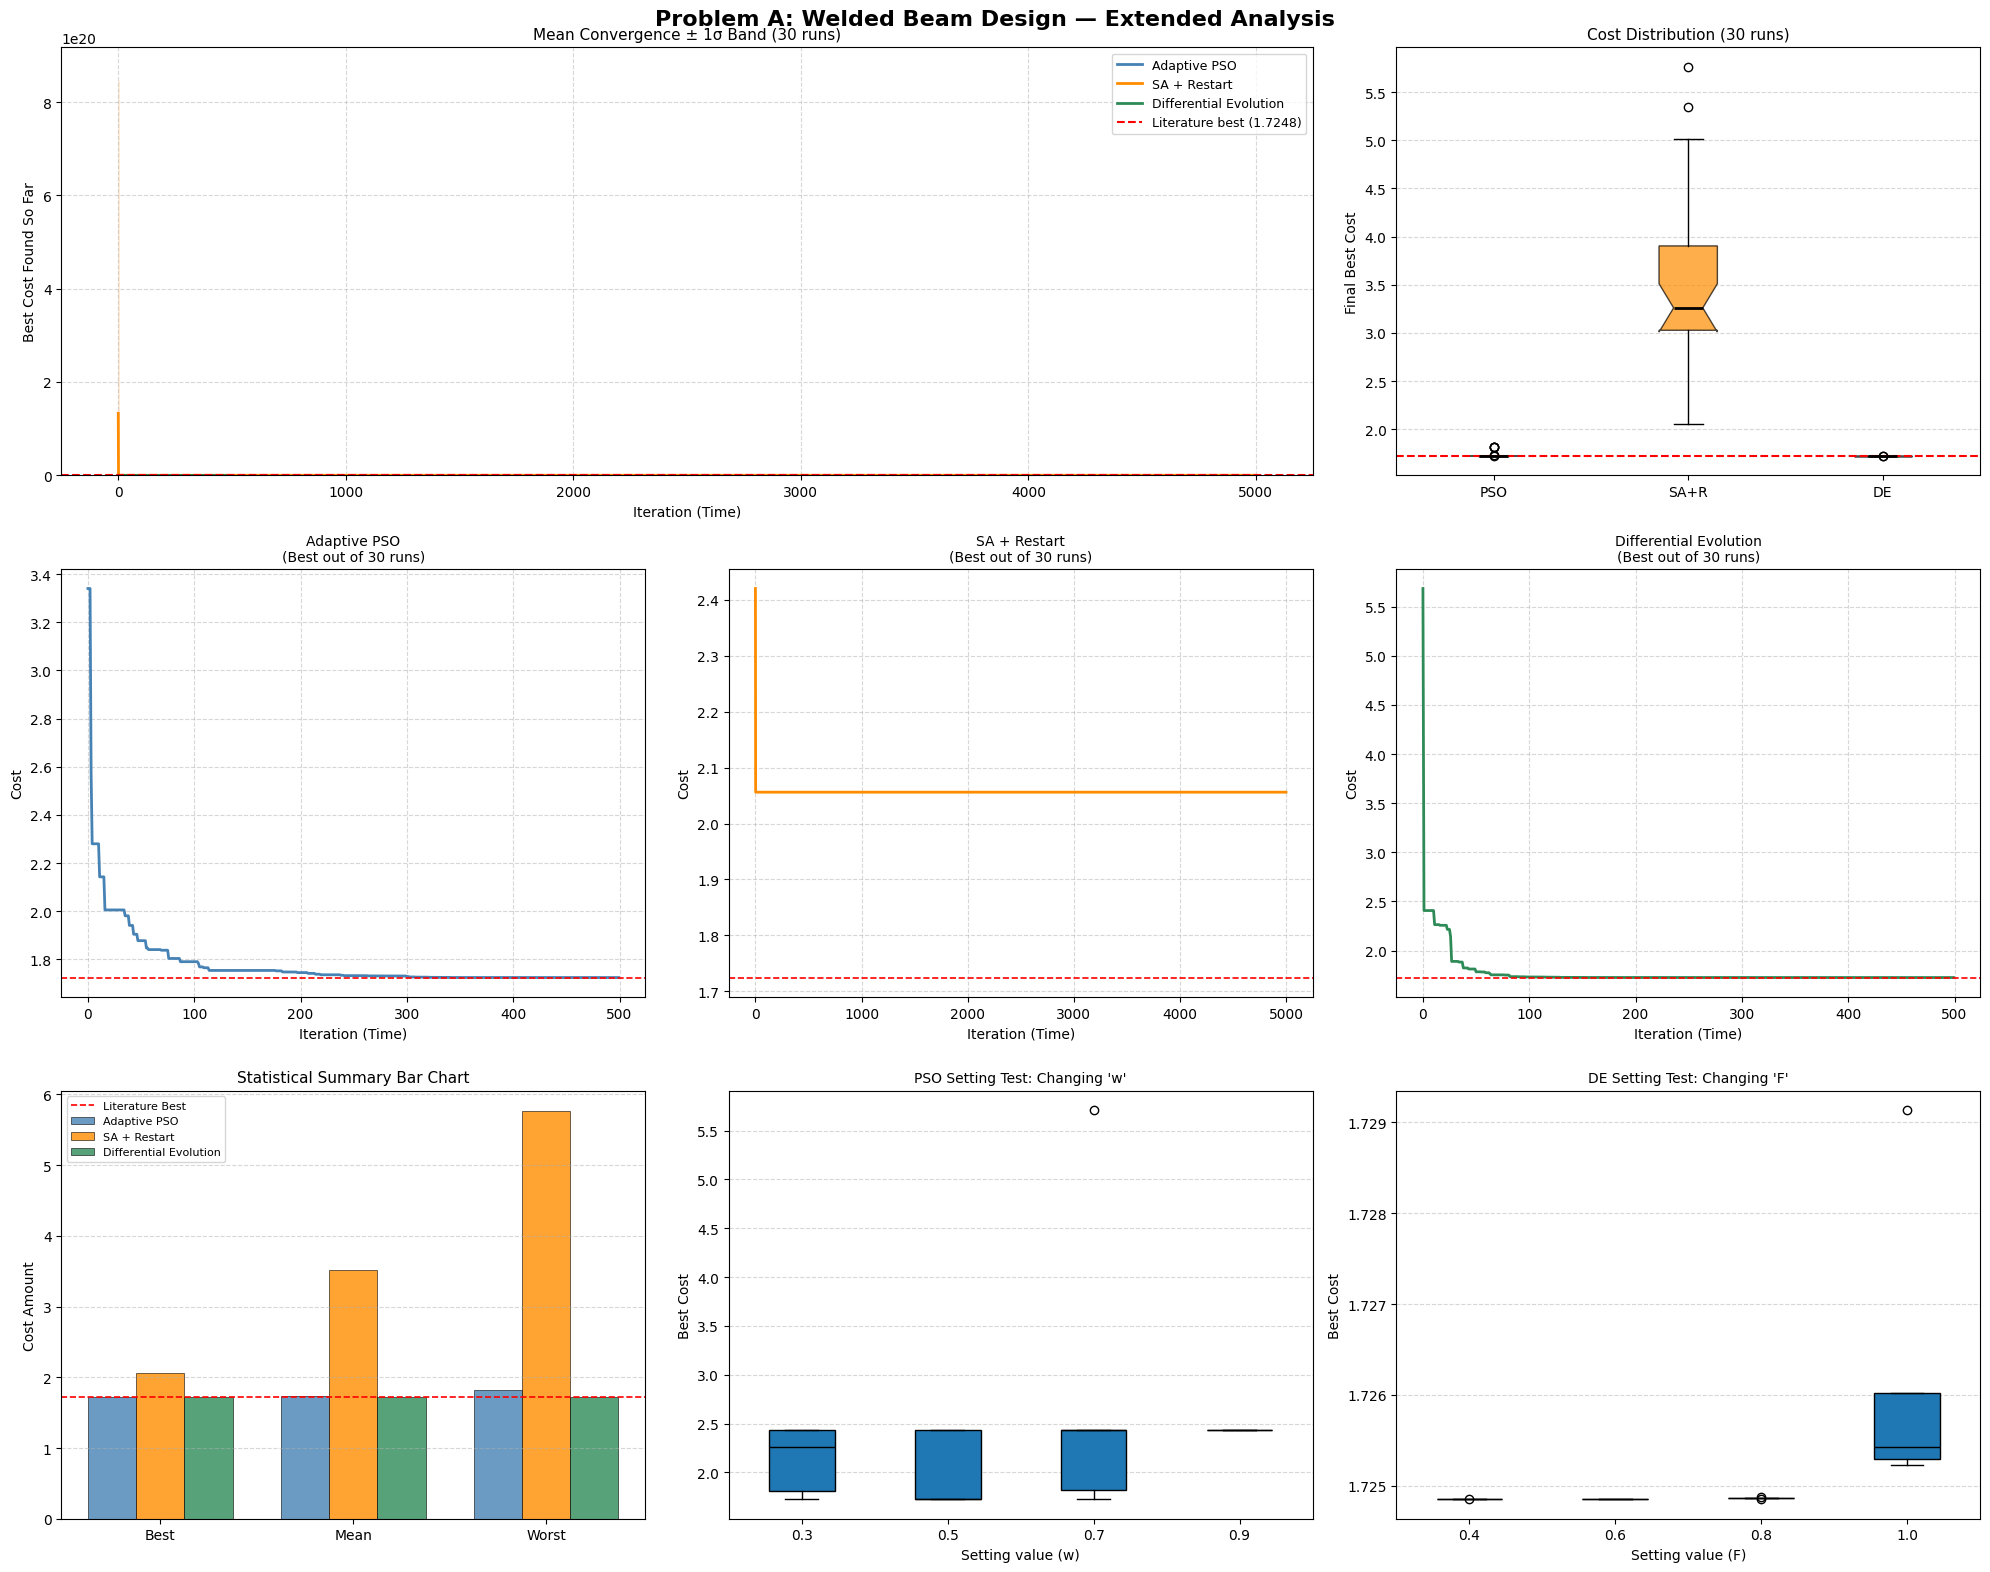


 Extended plot saved as 'welded_beam_extended.png'

  FINAL STATISTICAL COMPARISON TABLE (Across 30 runs)
  Algorithm                 Best Score   Average Deviation Worst Score
  ------------------------- ---------- --------- --------- -----------
  Adaptive PSO                 1.72485   1.73730   0.03029     1.81429
  SA + Restart                 2.05603   3.52327   0.91875     5.76325
  Differential Evolution       1.72485   1.72485   0.00000     1.72485
  Literature Best               1.7248         —         —           —

 Problem A Complete!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random, math, time
from copy import deepcopy

np.random.seed(0)
random.seed(0)

# ==============================================================
# 1. SETTING UP THE PROBLEM (Measurements & Limits)
# ==============================================================
# Here we define the physical rules of our welded beam.
P         = 6000.0     # The weight (load) pushing down on the beam
L         = 14.0       # The length of the beam
E         = 30e6       # How stiff the material is (Young's modulus)
G         = 12e6       # How well the material resists twisting (Shear modulus)

# These are our absolute safety limits. If the beam passes these, it breaks!
TAU_MAX   = 13600.0    # Maximum shear stress
SIGMA_MAX = 30000.0    # Maximum bending stress
DELTA_MAX = 0.25       # Maximum amount the beam is allowed to bend/sag

# We are trying to find the perfect size for 4 parts of the beam:
# [weld thickness, weld length, beam thickness, beam width]
LB = np.array([0.1, 0.1, 0.1, 0.1])    # The absolute smallest sizes allowed
UB = np.array([2.0, 10.0, 10.0, 2.0])  # The absolute largest sizes allowed
DIM = 4                                # We have 4 variables to figure out

# ==============================================================
# 2. MATH FORMULAS: Cost and Safety Checks
# ==============================================================
def objective(x):
    # This formula calculates how much money it costs to build the beam.
    # Our main goal is to make this number as small as possible.
    h, l, t, b = x
    return 1.10471 * h**2 * l + 0.04811 * t * b * (14.0 + l)

def constraint_violations(x):
    # This checks if our proposed beam is actually safe to use.
    h, l, t, b = x
    try:
        # Complex engineering math to figure out the stress on the metal
        M  = P * (L + l / 2.0)
        R  = math.sqrt(0.25 * (l**2 + (h + t)**2))
        J  = 2.0 * (math.sqrt(2) * h * l * (l**2 / 12.0 + 0.25 * (h + t)**2))
        tau_d  = P / (math.sqrt(2) * h * l)
        tau_dd = M * R / J
        tau    = math.sqrt(tau_d**2 + tau_d * tau_dd * l / R + tau_dd**2)
        sigma  = 6.0 * P * L / (b * t**2)
        delta  = 4.0 * P * L**3 / (E * b * t**3)
        Pc     = (4.013 * E * math.sqrt(t**2 * b**6 / 36.0) / L**2) \
                 * (1.0 - t / (2.0 * L) * math.sqrt(E / (4.0 * G)))

        # We return 5 scores. If a score is negative, that safety check PASSED.
        # If a score is positive, the beam fails that safety check.
        g = [
            tau   - TAU_MAX,     # Check 1: Does the weld break?
            sigma - SIGMA_MAX,   # Check 2: Does the beam snap?
            h     - b,           # Check 3: Is the weld thicker than the beam? (It shouldn't be)
            delta - DELTA_MAX,   # Check 4: Does it sag too much?
            P     - Pc           # Check 5: Will it buckle under pressure?
        ]
        return g
    except:
        # If the math crashes (like dividing by zero), treat it as a massive failure.
        return [1e6] * 5

def penalty_fitness(x):
    # This is how we train the AI to follow the rules.
    # If the AI suggests a beam size outside our limits, we give it a massive fake cost (1 billion).
    if np.any(x < LB) or np.any(x > UB):
        return 1e9

    # If it breaks safety rules, we add a huge "penalty fee" to the actual cost.
    # This forces the AI to look for cheaper designs that are ALSO safe.
    g = constraint_violations(x)
    penalty = 1e6 * sum(max(0.0, gi)**2 for gi in g)
    return objective(x) + penalty

def is_feasible(x):
    # A simple Yes/No check: Are all 5 safety rules met?
    g = constraint_violations(x)
    return all(gi <= 0 for gi in g)

# ==============================================================
# 3. ALGORITHM 1: PARTICLE SWARM (Like a flock of birds)
# ==============================================================
def adaptive_pso(n_particles=40, max_iter=500):
    # Imagine 40 birds (particles) flying over a valley, looking for the lowest point (lowest cost).
    w_start, w_end = 0.9, 0.4
    c1, c2 = 2.0, 2.0

    # Start the birds at random locations
    pos = LB + np.random.rand(n_particles, DIM) * (UB - LB)
    vel = np.zeros((n_particles, DIM)) # Speed of the birds
    pbest_pos = pos.copy()             # Each bird remembers its own personal best spot
    pbest_fit = np.array([penalty_fitness(p) for p in pos])

    # Find the one bird that found the absolute best spot so far
    g_idx     = np.argmin(pbest_fit)
    gbest_pos = pbest_pos[g_idx].copy()
    gbest_fit = pbest_fit[g_idx]

    convergence = [] # We use this to track how fast the flock finds the answer

    # Let the birds fly around for 'max_iter' amount of time
    for it in range(max_iter):
        # Slowly calm the birds down. At first they fly wildly to explore everywhere.
        # Later, they slow down to inspect the best spots closely.
        w = w_start - (w_start - w_end) * it / max_iter

        for i in range(n_particles):
            r1 = np.random.rand(DIM)
            r2 = np.random.rand(DIM)

            # Update bird speed: pull them toward their own best spot, AND the flock's best spot
            vel[i] = (w * vel[i]
                      + c1 * r1 * (pbest_pos[i] - pos[i])
                      + c2 * r2 * (gbest_pos    - pos[i]))

            # Move the bird, making sure it doesn't fly outside our limits
            vel[i] = np.clip(vel[i], -(UB - LB) * 0.5, (UB - LB) * 0.5)
            pos[i] = np.clip(pos[i] + vel[i], LB, UB)

            # Check if the new spot is better than before
            f = penalty_fitness(pos[i])
            if f < pbest_fit[i]:
                pbest_fit[i] = f
                pbest_pos[i] = pos[i].copy()
            # Check if this new spot is the best the ENTIRE flock has ever seen
            if f < gbest_fit:
                gbest_fit = f
                gbest_pos = pos[i].copy()

        convergence.append(gbest_fit)

    return gbest_pos, gbest_fit, convergence

# ==============================================================
# 4. ALGORITHM 2: SIMULATED ANNEALING (Like cooling metal)
# ==============================================================
def sa_with_restart(max_iter=5000, T_init=1000, alpha=0.995, restart_threshold=500):
    # This method mimics blacksmithing. Hot metal is flexible, cold metal is locked in.
    # We start 'hot' (accepting bad designs just to explore) and slowly 'cool' down.
    current   = LB + np.random.rand(DIM) * (UB - LB)
    current_f = penalty_fitness(current)

    best   = current.copy()
    best_f = current_f

    T = T_init       # Temperature starts high
    T_min   = 1e-5   # Coldest temperature
    no_imp  = 0      # Track how long we've been stuck without finding a better design
    convergence = []

    for it in range(max_iter):
        # Pick a random neighbor design near our current design
        step     = (UB - LB) * 0.05 * (T / T_init + 0.01)
        neighbor = np.clip(current + np.random.uniform(-step, step, DIM), LB, UB)
        nbr_f    = penalty_fitness(neighbor)
        delta    = nbr_f - current_f

        # If the neighbor is cheaper, OR if we are hot enough to accept a worse design randomly
        if delta < 0 or (T > T_min and random.random() < math.exp(-delta / T)):
            current   = neighbor.copy()
            current_f = nbr_f

        # Keep track of the absolute best design we've ever seen
        if current_f < best_f:
            best_f  = current_f
            best    = current.copy()
            no_imp  = 0 # Reset our "stuck" counter
        else:
            no_imp += 1

        # If we've been stuck in a rut for too long, teleport to a random new location and try again
        if no_imp >= restart_threshold:
            current   = LB + np.random.rand(DIM) * (UB - LB)
            current_f = penalty_fitness(current)
            T         = T_init * 0.5
            no_imp    = 0

        # Cool down the temperature slightly for the next round
        T = max(T * alpha, T_min)
        convergence.append(best_f)

    return best, best_f, convergence

# ==============================================================
# 5. ALGORITHM 3: DIFFERENTIAL EVOLUTION (Genetic mixing)
# ==============================================================
def differential_evolution(pop_size=40, max_iter=500, F=0.8, CR=0.9):
    # This works like genetics. We take multiple designs, "breed" them together,
    # and if the child is better than the parent, the child survives to the next generation.

    # Create an initial population of random beam designs
    pop = LB + np.random.rand(pop_size, DIM) * (UB - LB)
    fit = np.array([penalty_fitness(p) for p in pop])

    best_idx = np.argmin(fit)
    best     = pop[best_idx].copy()
    best_f   = fit[best_idx]

    convergence = []

    for gen in range(max_iter):
        for i in range(pop_size):
            # Pick 3 random, completely different designs from the population
            candidates = list(range(pop_size))
            candidates.remove(i)
            r1, r2, r3 = random.sample(candidates, 3)

            # Mutate them together to create a weird new hybrid design
            mutant = pop[r1] + F * (pop[r2] - pop[r3])
            mutant = np.clip(mutant, LB, UB)

            # Crossover: Mix the hybrid design with the current parent design
            jrand  = random.randint(0, DIM - 1)
            trial  = np.array([
                mutant[j] if (random.random() < CR or j == jrand) else pop[i][j]
                for j in range(DIM)
            ])
            trial = np.clip(trial, LB, UB)

            # Survival of the fittest: Does this new child cost less than the parent?
            trial_f = penalty_fitness(trial)
            if trial_f <= fit[i]:
                pop[i] = trial       # Child replaces parent
                fit[i] = trial_f

                # Check if this child is the best design out of EVERYONE
                if trial_f < best_f:
                    best_f = trial_f
                    best   = trial.copy()

        convergence.append(best_f)

    return best, best_f, convergence

# ==============================================================
# 6. RUNNING THE EXPERIMENT (Testing each method 30 times)
# ==============================================================
# We test each algorithm 30 times because they use randomness.
# Testing them once isn't fair; testing them 30 times shows which one is consistently the best.
N_RUNS = 30
print("=" * 62)
print("  PROBLEM A (EXTENDED): Welded Beam Design Optimization")
print("=" * 62)
print(f"\n  Running {N_RUNS} independent runs per algorithm...\n")

algorithms = {
    "Adaptive PSO": adaptive_pso,
    "SA + Restart": sa_with_restart,
    "Differential Evolution": differential_evolution,
}

# Dictionaries to save the test scores
all_results   = {}
all_conv      = {}
all_solutions = {}

LITERATURE_BEST = 1.7248 # The best known mathematical answer in history

# Loop through our 3 algorithms one by one
for name, algo in algorithms.items():
    print(f"  🔁 {name}:", end=" ", flush=True)
    results   = []
    conv_list = []
    best_overall   = None
    best_overall_f = np.inf

    t0 = time.time() # Start a stopwatch

    # Run the current algorithm 30 times
    for run in range(N_RUNS):
        # Set seeds so runs are different from each other, but exactly repeatable later
        np.random.seed(run * 7)
        random.seed(run * 7)

        # Actually run the algorithm and get the results
        sol, f, conv = algo()
        results.append(f)
        conv_list.append(conv)

        # Save the absolute best design found across all 30 tries
        if f < best_overall_f:
            best_overall_f = f
            best_overall   = sol.copy()

        # Print a dot every 10 runs to show progress on the screen
        if (run + 1) % 10 == 0:
            print(f"{run+1}.", end=" ", flush=True)

    elapsed = time.time() - t0 # Stop the stopwatch

    # Store the final stats for this algorithm
    all_results[name]   = results
    all_conv[name]      = conv_list
    all_solutions[name] = best_overall

    # Print the average score, the best score, and how long it took
    arr = np.array(results)
    print(f"\n     Best={arr.min():.5f}  Mean={arr.mean():.5f}  "
          f"Std={arr.std():.5f}  Worst={arr.max():.5f}  "
          f"Time={elapsed:.1f}s")

# ==============================================================
# 7. PRINTING THE BEST BEAM DESIGNS
# ==============================================================
print("\n" + "=" * 62)
print("  BEST SOLUTION DETAILS")
print("=" * 62)
print(f"  {'Algorithm':<25} {'h':>8} {'l':>8} {'t':>8} {'b':>8} {'Cost':>10} {'Feasible':>10}")
print(f"  {'-'*25} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*10} {'-'*10}")

# Print the specific dimensions (h, l, t, b) that each algorithm decided was the best
for name, sol in all_solutions.items():
    fval = objective(sol)
    feas = "✅ YES" if is_feasible(sol) else "❌ NO"
    print(f"  {name:<25} {sol[0]:>8.5f} {sol[1]:>8.5f} {sol[2]:>8.5f} "
          f"{sol[3]:>8.5f} {fval:>10.5f} {feas:>10}")

# Compare our findings to the famous historical answer
print(f"  {'Literature Best':<25} {'0.2088':>8} {'3.4205':>8} {'8.9975':>8} "
      f"{'0.2100':>8} {LITERATURE_BEST:>10.4f} {'✅ YES':>10}")

# ==============================================================
# 8. PRINTING THE SAFETY REPORT
# ==============================================================
print("\n" + "=" * 62)
print("  CONSTRAINT VIOLATIONS FOR BEST SOLUTIONS")
print("=" * 62)
constraint_names = ["Shear stress", "Bending stress", "Geometry", "Deflection", "Buckling"]

# Go through the best design from each algorithm and verify exactly how safe it is
for name, sol in all_solutions.items():
    g = constraint_violations(sol)
    print(f"\n  {name}:")
    for cn, gv in zip(constraint_names, g):
        # Remember, if the score is negative, the safety rule is satisfied.
        status = "✅ satisfied" if gv <= 0 else f"❌ violated by {gv:.4f}"
        print(f"    g({cn:<16}) = {gv:>10.5f}  {status}")

# ==============================================================
# 9. DRAWING GRAPHS AND CHARTS
# ==============================================================
colors = {
    "Adaptive PSO"          : "steelblue",
    "SA + Restart"          : "darkorange",
    "Differential Evolution": "seagreen",
}

# Create a massive blank canvas for 8 different charts
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Problem A: Welded Beam Design — Extended Analysis",
             fontsize=16, fontweight='bold', y=0.98)

# CHART 1: Shows the average learning curve over time for all algorithms
ax1 = fig.add_subplot(3, 3, (1, 2))
for name, conv_list in all_conv.items():
    min_len = min(len(c) for c in conv_list)
    arr = np.array([c[:min_len] for c in conv_list])
    mean_c = arr.mean(axis=0)
    std_c  = arr.std(axis=0)
    iters  = np.arange(min_len)
    ax1.plot(iters, mean_c, color=colors[name], linewidth=2, label=name)
    ax1.fill_between(iters, mean_c - std_c, mean_c + std_c, color=colors[name], alpha=0.15)

ax1.axhline(LITERATURE_BEST, color='red', linestyle='--',
            linewidth=1.5, label=f'Literature best ({LITERATURE_BEST})')
ax1.set_title("Mean Convergence ± 1σ Band (30 runs)", fontsize=11)
ax1.set_xlabel("Iteration (Time)")
ax1.set_ylabel("Best Cost Found So Far")
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylim(bottom=1.0)

# CHART 2: Boxplot - Visualizes how consistent each algorithm is across the 30 tries
ax2 = fig.add_subplot(3, 3, 3)
data_bp  = [all_results[n] for n in algorithms]
bp = ax2.boxplot(data_bp, patch_artist=True, notch=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, name in zip(bp['boxes'], algorithms):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.7)
ax2.set_xticks(range(1, len(algorithms) + 1))
ax2.set_xticklabels(["PSO", "SA+R", "DE"], fontsize=10)
ax2.axhline(LITERATURE_BEST, color='red', linestyle='--', linewidth=1.5)
ax2.set_title("Cost Distribution (30 runs)", fontsize=11)
ax2.set_ylabel("Final Best Cost")
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

# CHARTS 3, 4, 5: Look at the absolute best single run for each specific algorithm
for idx, (name, conv_list) in enumerate(all_conv.items()):
    ax = fig.add_subplot(3, 3, 4 + idx)
    best_run = np.argmin(all_results[name])
    ax.plot(conv_list[best_run], color=colors[name], linewidth=2)
    ax.axhline(LITERATURE_BEST, color='red', linestyle='--', linewidth=1.2)
    ax.set_title(f"{name}\n(Best out of 30 runs)", fontsize=10)
    ax.set_xlabel("Iteration (Time)")
    ax.set_ylabel("Cost")
    ax.grid(True, linestyle='--', alpha=0.5)

# CHART 6: Bar chart comparing the Best, Average, and Worst scores of each method
ax6 = fig.add_subplot(3, 3, 7)
metrics = ['Best', 'Mean', 'Worst']
x_pos   = np.arange(len(metrics))
width   = 0.25
for i, (name, results) in enumerate(all_results.items()):
    arr = np.array(results)
    vals = [arr.min(), arr.mean(), arr.max()]
    ax6.bar(x_pos + i * width, vals, width, label=name,
            color=colors[name], alpha=0.8, edgecolor='black', linewidth=0.5)
ax6.axhline(LITERATURE_BEST, color='red', linestyle='--',
            linewidth=1.2, label='Literature Best')
ax6.set_xticks(x_pos + width)
ax6.set_xticklabels(metrics)
ax6.set_title("Statistical Summary Bar Chart", fontsize=11)
ax6.set_ylabel("Cost Amount")
ax6.legend(fontsize=8)
ax6.grid(True, axis='y', linestyle='--', alpha=0.5)

# CHART 7: Seeing what happens if we change the "inertia" setting inside the PSO algorithm
ax7 = fig.add_subplot(3, 3, 8)
w_values = [0.3, 0.5, 0.7, 0.9]
w_results = []
for w_val in w_values:
    run_res = []
    # Test each setting 5 times to get an average
    for r in range(5):
        np.random.seed(r)
        random.seed(r)

        # A tiny version of PSO just for this test
        pos = LB + np.random.rand(40, DIM) * (UB - LB)
        vel = np.zeros((40, DIM))
        pbf = np.array([penalty_fitness(p) for p in pos])
        gp  = pos[np.argmin(pbf)].copy()
        gf  = pbf.min()
        for it in range(300):
            for i in range(40):
                r1, r2 = np.random.rand(DIM), np.random.rand(DIM)
                vel[i] = w_val*vel[i] + 2.0*r1*(pos[np.argmin(pbf)]-pos[i]) + 2.0*r2*(gp-pos[i])
                pos[i] = np.clip(pos[i]+vel[i], LB, UB)
                f = penalty_fitness(pos[i])
                if f < pbf[i]:
                    pbf[i] = f;
                    if f < gf: gf = f; gp = pos[i].copy()
        run_res.append(gf)
    w_results.append(run_res)

ax7.boxplot(w_results, positions=range(len(w_values)),
            patch_artist=True, medianprops=dict(color='black'))
ax7.set_xticks(range(len(w_values)))
ax7.set_xticklabels([str(w) for w in w_values])
ax7.set_title("PSO Setting Test: Changing 'w'", fontsize=10)
ax7.set_xlabel("Setting value (w)")
ax7.set_ylabel("Best Cost")
ax7.grid(True, axis='y', linestyle='--', alpha=0.5)

# CHART 8: Seeing what happens if we change the "mutation" setting inside the DE algorithm
ax8 = fig.add_subplot(3, 3, 9)
F_values = [0.4, 0.6, 0.8, 1.0]
F_results = []
for F_val in F_values:
    run_res = []
    # Test each setting 5 times
    for r in range(5):
        np.random.seed(r)
        random.seed(r)
        _, f, _ = differential_evolution(F=F_val, max_iter=300)
        run_res.append(f)
    F_results.append(run_res)

ax8.boxplot(F_results, positions=range(len(F_values)),
            patch_artist=True, medianprops=dict(color='black'))
ax8.set_xticks(range(len(F_values)))
ax8.set_xticklabels([str(f) for f in F_values])
ax8.set_title("DE Setting Test: Changing 'F'", fontsize=10)
ax8.set_xlabel("Setting value (F)")
ax8.set_ylabel("Best Cost")
ax8.grid(True, axis='y', linestyle='--', alpha=0.5)

# Save the master chart to your computer as an image file!
plt.tight_layout()
plt.savefig("welded_beam_extended.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Extended plot saved as 'welded_beam_extended.png'")

# ==============================================================
# 10. FINAL SUMMARY TABLE
# ==============================================================
# Print a clean, easy-to-read table showing exactly who won the experiment.
print("\n" + "=" * 62)
print("  FINAL STATISTICAL COMPARISON TABLE (Across 30 runs)")
print("=" * 62)
print(f"  {'Algorithm':<25} {'Best Score':>10} {'Average':>9} {'Deviation':>9} {'Worst Score':>11}")
print(f"  {'-'*25} {'-'*10} {'-'*9} {'-'*9} {'-'*11}")
for name, results in all_results.items():
    arr = np.array(results)
    print(f"  {name:<25} {arr.min():>10.5f} {arr.mean():>9.5f} "
          f"{arr.std():>9.5f} {arr.max():>11.5f}")
print(f"  {'Literature Best':<25} {LITERATURE_BEST:>10.4f} {'—':>9} {'—':>9} {'—':>11}")

print("\n Problem A Complete!")